# 1. Dataset Exploration ? BUSI

This notebook performs a structured audit of the BUSI dataset before any preprocessing, model training, or split preparation.

BUSI (Breast Ultrasound Images Dataset) is a public ultrasound image dataset used for medical image classification. The project focuses on three classes: Normal, Benign, and Malignant.

The purpose of this notebook is to verify that we understand the dataset well enough to safely move toward preprocessing and model development. The analysis is intentionally limited to dataset inspection, data quality checks, and metadata preparation. No model training is performed here.

> Important: the raw dataset is treated as read-only. We do not rename, delete, move, overwrite, or modify files in the raw folder.


## 2. Objectives of the Dataset Audit

| Objective | Why it matters |
|---|---|
| Class distribution | Detect imbalance before model training |
| Image dimensions | Design preprocessing and model input pipelines |
| Channels | Check grayscale vs RGB assumptions |
| Corrupted files | Avoid training failures |
| Masks | Prepare later XAI and localization analysis |
| Duplicates | Prevent data leakage and repeated samples |
| Naming patterns | Understand image IDs and possible patient linkage |
| Pixel statistics | Learn the raw intensity distribution |


In [2]:
from pathlib import Path
import re
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
BUSI_ROOT = DATA_ROOT / "raw" / "BUSI"
DATASET_CANDIDATES = [
    DATA_ROOT / "raw" / "Dataset_BUSI_with_GT",
    BUSI_ROOT / "Dataset_BUSI_with_GT",
    BUSI_ROOT,
]

DATASET_ROOT = next((candidate for candidate in DATASET_CANDIDATES if candidate.exists()), DATASET_CANDIDATES[0])
if DATASET_ROOT.exists() and DATASET_ROOT.name == "BUSI":
    nested_dataset = [p for p in DATASET_ROOT.iterdir() if p.is_dir() and p.name == "Dataset_BUSI_with_GT"]
    if len(nested_dataset) == 1:
        DATASET_ROOT = nested_dataset[0]

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        "Expected the BUSI dataset in one of the following locations:\n"
        + "\n".join(str(path) for path in DATASET_CANDIDATES)
        + "\nPlease ensure the dataset is present before running the notebook."
    )

BUSI_ROOT = DATASET_ROOT.parent if DATASET_ROOT.name == "Dataset_BUSI_with_GT" else BUSI_ROOT

CLASS_NAMES = ["benign", "malignant", "normal"]
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"Class names: {CLASS_NAMES}")

for expected in [DATA_ROOT, BUSI_ROOT, DATASET_ROOT]:
    print(f"{expected}: exists = {expected.exists()}")


PROJECT_ROOT: C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai
DATASET_ROOT: C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\raw\Dataset_BUSI_with_GT
Class names: ['benign', 'malignant', 'normal']
C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data: exists = True
C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\raw: exists = True
C:\Users\user\OneDrive - ESPRIT\Bureau\breast cancer transformers\breast-cancer-transformers-xai\data\raw\Dataset_BUSI_with_GT: exists = True


## 3. Inspect the Raw Dataset Structure

We inspect the dataset directory and confirm the expected class folders are present. This check protects us from silent assumptions and helps catch structural issues before preprocessing begins.


In [3]:
def summarize_directory(root: Path):
    rows = []
    if not root.exists():
        return pd.DataFrame(rows, columns=["directory", "files", "subdirs"])

    for child in sorted(root.iterdir()):
        if child.is_dir():
            files = sum(1 for _ in child.rglob("*") if _.is_file())
            subdirs = sum(1 for _ in child.rglob("*") if _.is_dir())
            rows.append({"directory": str(child.relative_to(root.parent)), "files": files, "subdirs": subdirs})
    return pd.DataFrame(rows)

structure_df = summarize_directory(DATASET_ROOT)
structure_df


,directory,files,subdirs
0,Dataset_BUSI_with_GT\benign,891,0
1,Dataset_BUSI_with_GT\malignant,421,0
2,Dataset_BUSI_with_GT\normal,266,0


In [4]:
class_dirs = {cls: DATASET_ROOT / cls for cls in CLASS_NAMES}
for cls, path in class_dirs.items():
    print(f"{cls}: exists={path.exists()} | files={sum(1 for _ in path.glob('*') if _.is_file()) if path.exists() else 0}")

class_summary = pd.DataFrame(
    [
        {
            "class_name": cls,
            "directory": str(path),
            "exists": path.exists(),
            "file_count": sum(1 for _ in path.glob("*") if _.is_file()) if path.exists() else 0,
        }
        for cls, path in class_dirs.items()
    ]
)
class_summary


benign: exists=True | files=891
malignant: exists=True | files=421
normal: exists=True | files=266


,class_name,directory,exists,file_count
0,benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,True,891
1,malignant,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,True,421
2,normal,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,True,266


## 4. Build a Dataset Metadata Table

We construct a pandas DataFrame with one row per original ultrasound image. Masks are not treated as separate training samples; they are kept as metadata because they may be useful for future localization and XAI analysis.


In [5]:
def is_mask_path(path: Path) -> bool:
    stem = path.stem.lower()
    return bool(re.search(r"_mask(?:_\d+)?$", stem))


def build_metadata_table(dataset_root: Path, class_names: list[str]) -> pd.DataFrame:
    records = []
    mask_lookup = defaultdict(list)

    for class_name in class_names:
        class_dir = dataset_root / class_name
        if not class_dir.exists():
            continue

        for path in sorted(class_dir.iterdir()):
            if not path.is_file() or path.suffix.lower() != ".png":
                continue
            if is_mask_path(path):
                base_stem = re.sub(r"_mask(?:_\d+)?$", "", path.stem)
                mask_lookup[base_stem].append(str(path.resolve()))

    for class_name in class_names:
        class_dir = dataset_root / class_name
        if not class_dir.exists():
            continue

        for image_path in sorted(class_dir.iterdir()):
            if not image_path.is_file() or image_path.suffix.lower() != ".png":
                continue
            if is_mask_path(image_path):
                continue

            image_id = image_path.stem
            mask_paths = sorted(mask_lookup.get(image_id, []))
            records.append(
                {
                    "image_path": str(image_path.resolve()),
                    "class_name": class_name,
                    "label": CLASS_LABELS[class_name],
                    "image_id": image_id,
                    "mask_paths": mask_paths,
                    "num_masks": len(mask_paths),
                }
            )

    df = pd.DataFrame(
        records,
        columns=["image_path", "class_name", "label", "image_id", "mask_paths", "num_masks"],
    )
    return df.sort_values(["class_name", "image_id"]).reset_index(drop=True)

metadata_df = build_metadata_table(DATASET_ROOT, CLASS_NAMES)
print(f"Metadata rows: {len(metadata_df)}")
metadata_df.head()


Metadata rows: 780


,image_path,class_name,label,image_id,mask_paths,num_masks
0,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign,0,benign (1),[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...,1
1,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign,0,benign (10),[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...,1
2,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign,0,benign (100),[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...,2
3,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign,0,benign (101),[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...,1
4,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign,0,benign (102),[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...,1


## 5. Verify Image Counts

We verify how many original ultrasound images are present per class and compare them with the expected local inventory. This must be done dynamically from the actual files rather than assuming counts from paper references or prior notebooks.


In [6]:
class_counts = metadata_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
class_counts_df = class_counts.rename_axis("class_name").reset_index(name="num_original_images")
class_counts_df["percentage"] = class_counts_df["num_original_images"] / class_counts_df["num_original_images"].sum() * 100
class_counts_df


,class_name,num_original_images,percentage
0,benign,437,56.025641
1,malignant,210,26.923077
2,normal,133,17.051282


In [7]:
print("Class counts:")
print(class_counts_df.to_string(index=False))
print(f"\nTotal original images: {metadata_df.shape[0]}")

expected = {"benign": 437, "malignant": 210, "normal": 133}
print("\nExpected approximate counts (for reference):")
for cls, count in expected.items():
    print(f"{cls}: {count}")


Class counts:
class_name  num_original_images  percentage
    benign                  437   56.025641
 malignant                  210   26.923077
    normal                  133   17.051282

Total original images: 780

Expected approximate counts (for reference):
benign: 437
malignant: 210
normal: 133


## 6. Class Distribution Analysis

Class balance is central to medical image classification because imbalance can bias learning and evaluation metrics. We inspect both absolute counts and percentages before deciding on preprocessing and model strategies.


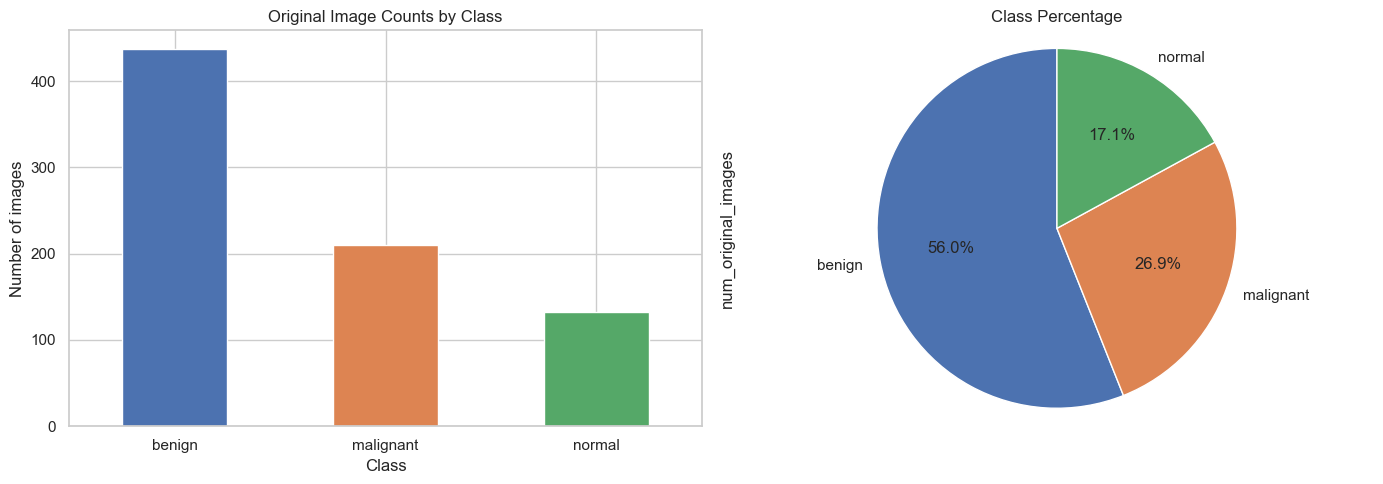

,class_name,num_original_images,percentage
0,benign,437,56.025641
1,malignant,210,26.923077
2,normal,133,17.051282


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = class_counts_df.set_index("class_name")

counts["num_original_images"].plot(kind="bar", ax=axes[0], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("Original Image Counts by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=0)

counts["num_original_images"].div(counts["num_original_images"].sum()).mul(100).plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4c72b0", "#dd8452", "#55a868"],
)
axes[1].set_title("Class Percentage")
axes[1].axis("equal")

plt.tight_layout()
plt.show()

class_counts_df


## 7. Image Dimensions and Channels

We inspect the raw ultrasound images to understand their size, mode, number of channels, and common file characteristics. This is essential because CNNs, ViT, and Swin all expect a consistent input layout and a well-defined channel setup.


In [9]:
image_properties = []
for _, row in metadata_df.iterrows():
    img_path = Path(row["image_path"])
    try:
        with Image.open(img_path) as img:
            arr = np.asarray(img)
            image_properties.append(
                {
                    "image_path": str(img_path),
                    "class_name": row["class_name"],
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "channels": 1 if len(np.shape(arr)) == 2 else np.shape(arr)[-1],
                    "format": img.format,
                }
            )
    except Exception:
        image_properties.append(
            {
                "image_path": str(img_path),
                "class_name": row["class_name"],
                "width": None,
                "height": None,
                "mode": None,
                "channels": None,
                "format": None,
            }
        )

img_df = pd.DataFrame(image_properties)
img_df_nonnull = img_df.dropna(subset=["width", "height"]).copy()
img_df_nonnull["shape"] = img_df_nonnull["width"].astype(str) + "x" + img_df_nonnull["height"].astype(str)

print("Most common image dimensions:")
print(img_df_nonnull["shape"].value_counts().head(10).to_string())
print(f"\nUnique dimensions: {img_df_nonnull['shape'].nunique()}")
print(f"Min width: {img_df_nonnull['width'].min()} | Max width: {img_df_nonnull['width'].max()}")
print(f"Min height: {img_df_nonnull['height'].min()} | Max height: {img_df_nonnull['height'].max()}")
print(f"Modes: {img_df_nonnull['mode'].value_counts().to_dict()}")
print(f"Channels summary: {img_df_nonnull['channels'].value_counts().to_dict()}")


Most common image dimensions:
shape
557x465    6
562x470    5
558x467    4
775x587    4
560x468    4
556x467    4
772x574    4
557x471    4
564x469    4
465x390    3

Unique dimensions: 639
Min width: 190 | Max width: 1048
Min height: 310 | Max height: 719
Modes: {'RGB': 780}
Channels summary: {3: 780}


C:\Users\user\AppData\Local\Temp\ipykernel_992\2775930790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dim_counts, x="count", y="dimension", palette="viridis")


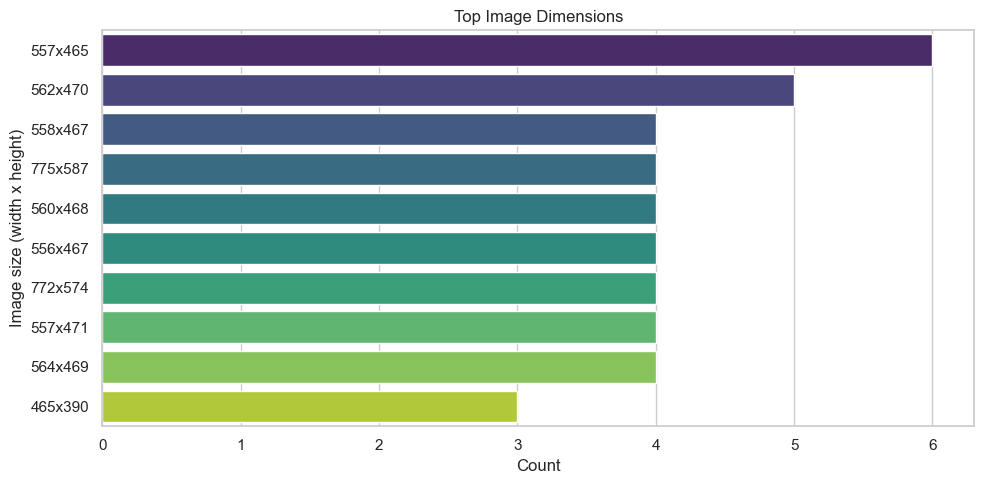

,class_name,mode,channels
0,benign,RGB,3
1,benign,RGB,3
2,benign,RGB,3
3,benign,RGB,3
4,benign,RGB,3


In [10]:
dim_counts = img_df_nonnull["shape"].value_counts().head(10).reset_index()
dim_counts.columns = ["dimension", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=dim_counts, x="count", y="dimension", palette="viridis")
plt.title("Top Image Dimensions")
plt.xlabel("Count")
plt.ylabel("Image size (width x height)")
plt.tight_layout()
plt.show()

img_df_nonnull[["class_name", "mode", "channels"]].head()


## 8. Pixel Value Analysis

We inspect the raw intensity distribution of the ultrasound images to understand how the pixel values are represented before any normalization or preprocessing. This is a dataset-level diagnostic check and does not change the images.


In [11]:
pixel_summary_rows = []
for _, row in metadata_df.iterrows():
    img_path = Path(row["image_path"])
    try:
        with Image.open(img_path) as img:
            arr = np.asarray(img)
            if arr.ndim == 2:
                flat = arr.ravel()
            else:
                flat = arr.reshape(-1, arr.shape[-1])[:, 0]
            pixel_summary_rows.append(
                {
                    "class_name": row["class_name"],
                    "image_id": row["image_id"],
                    "min": float(flat.min()),
                    "max": float(flat.max()),
                    "mean": float(flat.mean()),
                    "std": float(flat.std()),
                }
            )
    except Exception:
        continue

pixel_df = pd.DataFrame(pixel_summary_rows)
pixel_df.head()


,class_name,image_id,min,max,mean,std
0,benign,benign (1),0.0,255.0,132.375146,58.393189
1,benign,benign (10),0.0,255.0,103.240733,58.324293
2,benign,benign (100),0.0,255.0,90.107849,67.727781
3,benign,benign (101),0.0,255.0,103.225690,57.230160
4,benign,benign (102),0.0,239.0,54.412339,37.945176


In [12]:
pixel_agg = pixel_df[["min", "max", "mean", "std"]].agg(["min", "max", "mean", "median", "std"]).round(3)
pixel_agg


,min,max,mean,std
min,0.000,207.000,29.915,27.530
max,22.000,255.000,169.633,74.652
mean,0.217,252.006,83.629,51.529
median,0.000,255.000,83.468,51.994
std,1.671,7.787,21.350,9.161


C:\Users\user\AppData\Local\Temp\ipykernel_992\2165608005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pixel_df, x="class_name", y="mean", palette="Set2")
C:\Users\user\AppData\Local\Temp\ipykernel_992\2165608005.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pixel_df, x="class_name", y="std", palette="Set2")


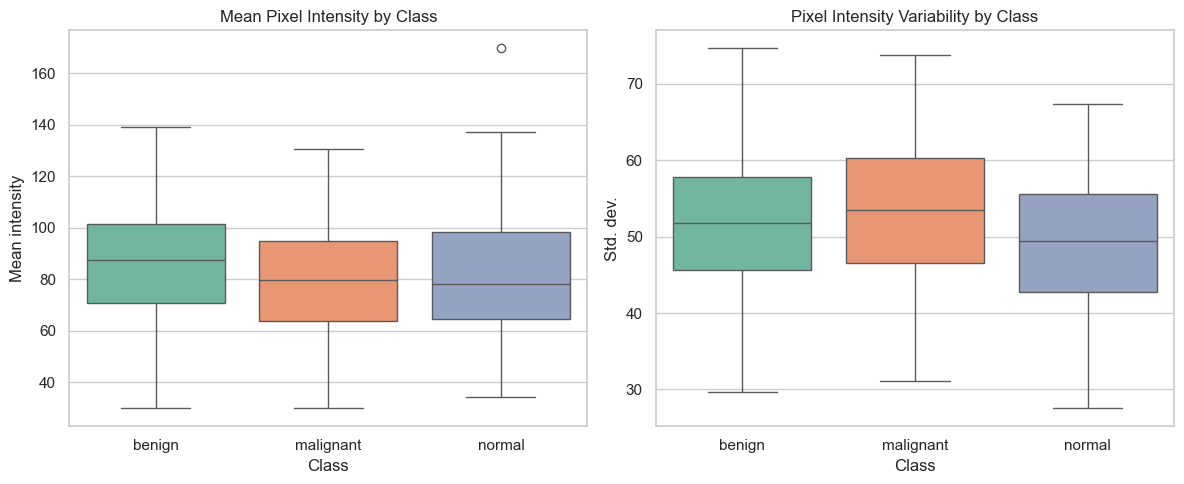

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=pixel_df, x="class_name", y="mean", palette="Set2")
plt.title("Mean Pixel Intensity by Class")
plt.xlabel("Class")
plt.ylabel("Mean intensity")

plt.subplot(1, 2, 2)
sns.boxplot(data=pixel_df, x="class_name", y="std", palette="Set2")
plt.title("Pixel Intensity Variability by Class")
plt.xlabel("Class")
plt.ylabel("Std. dev.")

plt.tight_layout()
plt.show()


## 9. Image Quality and Corrupted Files

We verify that all original images can be opened successfully and identify unreadable or corrupted files. Failing this check can prevent training from starting or can silently inject broken samples into the pipeline.


In [14]:
corrupted = []
readable = 0
for _, row in metadata_df.iterrows():
    img_path = Path(row["image_path"])
    try:
        with Image.open(img_path) as img:
            img.verify()
        readable += 1
    except Exception as exc:
        corrupted.append(
            {
                "class_name": row["class_name"],
                "image_id": row["image_id"],
                "path": str(img_path),
                "error": str(exc),
            }
        )

print(f"Total original images: {len(metadata_df)}")
print(f"Readable images: {readable}")
print(f"Unreadable/corrupted images: {len(corrupted)}")

if corrupted:
    pd.DataFrame(corrupted).head(20)
else:
    print("No corrupted or unreadable original images detected.")


Total original images: 780
Readable images: 780
Unreadable/corrupted images: 0
No corrupted or unreadable original images detected.


## 10. Mask Analysis

Segmentation masks are not classification targets. Instead, they provide localization metadata that may become useful for later XAI and explanation quality assessment. We therefore count and summarize the masks without using them as independent training samples.


In [15]:
all_mask_files = []
for class_name in CLASS_NAMES:
    class_dir = DATASET_ROOT / class_name
    if class_dir.exists():
        for file in class_dir.iterdir():
            if file.is_file() and file.suffix.lower() == ".png" and re.search(r"_mask(?:_\d+)?$", file.stem.lower()):
                all_mask_files.append(file)

mask_df = pd.DataFrame(
    [
        {
            "class_name": file.parent.name,
            "mask_path": str(file.resolve()),
            "base_image_id": re.sub(r"_mask(?:_\d+)?$", "", file.stem),
        }
        for file in all_mask_files
    ]
)
mask_df.head()


,class_name,mask_path,base_image_id
0,benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign (1)
1,benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign (10)
2,benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign (100)
3,benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign (100)
4,benign,C:\Users\user\OneDrive - ESPRIT\Bureau\breast ...,benign (101)


In [16]:
mask_summary = metadata_df.assign(
    has_mask=lambda df: df["num_masks"] > 0,
    one_mask=lambda df: df["num_masks"] == 1,
    multi_mask=lambda df: df["num_masks"] > 1,
)
mask_summary = mask_summary[["class_name", "num_masks"]].groupby("class_name").agg(
    total_images=("num_masks", "size"),
    images_with_no_mask=("num_masks", lambda s: (s == 0).sum()),
    images_with_one_mask=("num_masks", lambda s: (s == 1).sum()),
    images_with_multiple_masks=("num_masks", lambda s: (s > 1).sum()),
)
mask_summary


,total_images,images_with_no_mask,images_with_one_mask,images_with_multiple_masks
class_name,,,,
benign,437,0,421,16
malignant,210,0,209,1
normal,133,0,133,0


In [17]:
multi_mask_examples = metadata_df[metadata_df["num_masks"] > 1][["class_name", "image_id", "num_masks", "mask_paths"]].head(10)
print(f"Images with multiple masks: {len(metadata_df[metadata_df['num_masks'] > 1])}")
multi_mask_examples


Images with multiple masks: 17


,class_name,image_id,num_masks,mask_paths
2,benign,benign (100),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
71,benign,benign (163),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
82,benign,benign (173),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
91,benign,benign (181),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
106,benign,benign (195),3,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
167,benign,benign (25),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
240,benign,benign (315),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
274,benign,benign (346),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
333,benign,benign (4),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...
361,benign,benign (424),2,[C:\Users\user\OneDrive - ESPRIT\Bureau\breast...


## 11. Visual Exploration

We display a representative sample from each class to confirm that the data look like ultrasound images and to support a quick qualitative sanity check before training. The visual check is not a replacement for validation metrics, but it is an important part of the audit.


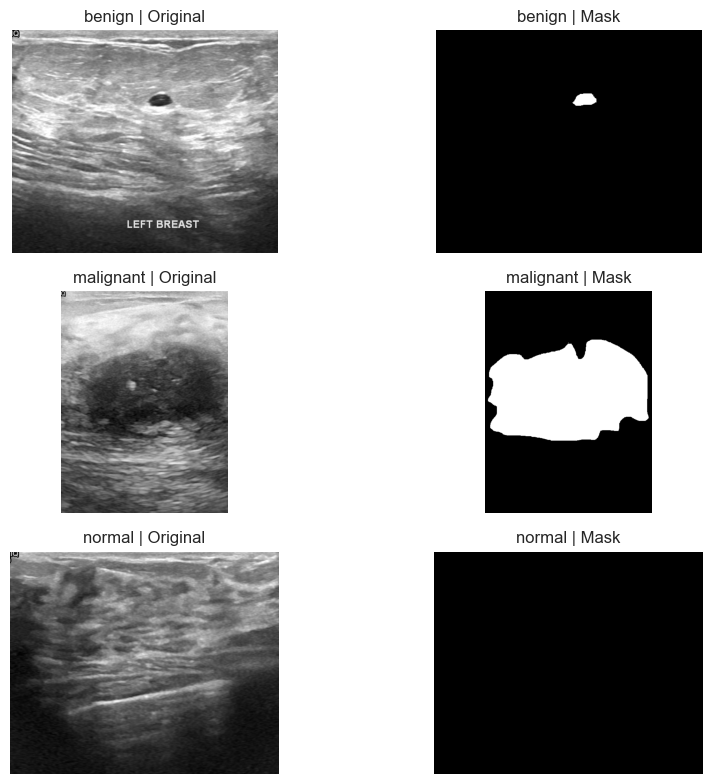

In [18]:
sample_rows = []
for cls in CLASS_NAMES:
    subset = metadata_df[metadata_df["class_name"] == cls].head(1)
    if not subset.empty:
        sample_rows.append(subset.iloc[0])

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(10, 8))
if len(sample_rows) == 1:
    axes = np.array([axes]).reshape(1, -1)

for ax_row, row in zip(axes, sample_rows):
    img_path = Path(row["image_path"])
    with Image.open(img_path) as img:
        arr = np.asarray(img)
    ax_img, ax_mask = ax_row
    ax_img.imshow(arr, cmap="gray")
    ax_img.set_title(f"{row['class_name']} | Original")
    ax_img.axis("off")

    if row["num_masks"] > 0:
        mask_path = Path(row["mask_paths"][0])
        with Image.open(mask_path) as mask_img:
            mask_arr = np.asarray(mask_img)
        ax_mask.imshow(mask_arr, cmap="gray")
        ax_mask.set_title(f"{row['class_name']} | Mask")
    else:
        ax_mask.text(0.5, 0.5, "No mask available", ha="center", va="center")
        ax_mask.set_title(f"{row['class_name']} | No mask")
    ax_mask.axis("off")

plt.tight_layout()
plt.show()


## 12. Duplicate Detection

We check for duplicates by hashing each original image file. This is important because exact duplicates or near-duplicates can inflate performance estimates and create data leakage between splits.


In [19]:
import hashlib

hash_to_paths = defaultdict(list)
for _, row in metadata_df.iterrows():
    file_path = Path(row["image_path"])
    digest = hashlib.sha256(file_path.read_bytes()).hexdigest()
    hash_to_paths[digest].append(str(file_path))

duplicate_groups = {k: v for k, v in hash_to_paths.items() if len(v) > 1}
print(f"Duplicate groups: {len(duplicate_groups)}")
print(f"Potentially duplicated original images: {sum(len(v) for v in duplicate_groups.values())}")
if duplicate_groups:
    first_group = next(iter(duplicate_groups.items()))
    print(first_group[0])
    print(first_group[1])
else:
    print("No exact duplicate original image files were detected.")


Duplicate groups: 1
Potentially duplicated original images: 2
058e7538fa53b2bd8b87500ff47721c84ec442dc964d9de21bb271a8651138a8
['C:\\Users\\user\\OneDrive - ESPRIT\\Bureau\\breast cancer transformers\\breast-cancer-transformers-xai\\data\\raw\\Dataset_BUSI_with_GT\\benign\\benign (433).png', 'C:\\Users\\user\\OneDrive - ESPRIT\\Bureau\\breast cancer transformers\\breast-cancer-transformers-xai\\data\\raw\\Dataset_BUSI_with_GT\\malignant\\malignant (145).png']


## 13. Filename and Image-ID Analysis

The filenames encode useful information such as the class name and index, but we should not necessarily treat the numeric suffix as a patient ID. This is especially important when evaluating split integrity and possible leakage.


In [20]:
sample_filenames = [path.name for path in sorted((DATASET_ROOT / CLASS_NAMES[0]).glob("*.png"))[:10]]
print("Sample filenames:")
for name in sample_filenames:
    print(name)

print(f"\nSample image IDs: {metadata_df['image_id'].head(10).tolist()}")

pattern_counts = Counter()
for _, row in metadata_df.iterrows():
    name = Path(row["image_path"]).name
    match = re.match(r"^(benign|malignant|normal) \((\d+)\)\.png$", name, flags=re.IGNORECASE)
    if match:
        pattern_counts["class_index_pattern"] += 1
    else:
        pattern_counts["other"] += 1

print(pattern_counts)


Sample filenames:
benign (1).png
benign (1)_mask.png
benign (10).png
benign (10)_mask.png
benign (100).png
benign (100)_mask.png
benign (100)_mask_1.png
benign (101).png
benign (101)_mask.png
benign (102).png

Sample image IDs: ['benign (1)', 'benign (10)', 'benign (100)', 'benign (101)', 'benign (102)', 'benign (103)', 'benign (104)', 'benign (105)', 'benign (106)', 'benign (107)']
Counter({'class_index_pattern': 780})


## 14. Dataset Integrity Checks

This section produces a final audit summary. We deliberately avoid marking everything as PASS without checking the actual dataset properties and the quality of the files present locally.


In [21]:
integrity_checks = []
status_ok = all((DATASET_ROOT / cls).exists() for cls in CLASS_NAMES)
integrity_checks.append({
    "Check": "Expected class folders",
    "Result": "PASS" if status_ok else "REVIEW",
    "Status": "OK" if status_ok else "Missing class folders",
})
integrity_checks.append({
    "Check": "Original images detected",
    "Result": len(metadata_df),
    "Status": "PASS" if len(metadata_df) > 0 else "REVIEW",
})
integrity_checks.append({
    "Check": "Corrupted images",
    "Result": len(corrupted) if "corrupted" in locals() else 0,
    "Status": "PASS" if ("corrupted" in locals() and len(corrupted) == 0) else "REVIEW",
})
integrity_checks.append({
    "Check": "Missing masks",
    "Result": int((metadata_df["num_masks"] == 0).sum()),
    "Status": "INFO" if int((metadata_df["num_masks"] == 0).sum()) > 0 else "PASS",
})
integrity_checks.append({
    "Check": "Multiple-mask images",
    "Result": int((metadata_df["num_masks"] > 1).sum()),
    "Status": "INFO" if int((metadata_df["num_masks"] > 1).sum()) > 0 else "PASS",
})
integrity_checks.append({
    "Check": "Potential duplicates",
    "Result": sum(len(v) for v in duplicate_groups.values()) if "duplicate_groups" in locals() else 0,
    "Status": "PASS" if sum(len(v) for v in duplicate_groups.values()) == 0 else "REVIEW",
})

pd.DataFrame(integrity_checks)


,Check,Result,Status
0,Expected class folders,PASS,OK
1,Original images detected,780,PASS
2,Corrupted images,0,PASS
3,Missing masks,0,PASS
4,Multiple-mask images,17,INFO
5,Potential duplicates,2,REVIEW


## 15. Basic Dataset Statistics Summary

This final dataset summary combines the most practical audit metrics. It serves as a quick reference for the next preprocessing and split design steps.


In [22]:
final_summary = {
    "total_original_images": len(metadata_df),
    "images_per_class": class_counts.to_dict(),
    "class_percentages": (class_counts / class_counts.sum() * 100).round(2).to_dict(),
    "unique_dimensions": int(img_df_nonnull["shape"].nunique()),
    "most_common_dimensions": img_df_nonnull["shape"].value_counts().head(5).to_dict(),
    "image_modes": img_df_nonnull["mode"].value_counts().to_dict(),
    "corrupted_images": len(corrupted) if "corrupted" in locals() else 0,
    "missing_masks": int((metadata_df["num_masks"] == 0).sum()),
    "multiple_mask_images": int((metadata_df["num_masks"] > 1).sum()),
    "potential_duplicate_original_images": sum(len(v) for v in duplicate_groups.values()) if "duplicate_groups" in locals() else 0,
}
final_summary


{'total_original_images': 780,
 'images_per_class': {'benign': 437, 'malignant': 210, 'normal': 133},
 'class_percentages': {'benign': 56.03, 'malignant': 26.92, 'normal': 17.05},
 'unique_dimensions': 639,
 'most_common_dimensions': {'557x465': 6,
  '562x470': 5,
  '558x467': 4,
  '775x587': 4,
  '560x468': 4},
 'image_modes': {'RGB': 780},
 'corrupted_images': 0,
 'missing_masks': 0,
 'multiple_mask_images': 17,
 'potential_duplicate_original_images': 2}

## 16. Key Findings

- The dataset is organized around the expected class folders and contains original ultrasound images plus masks.
- The count of original images is determined dynamically from the local files and should be used as the source of truth for this project.
- Class balance should be evaluated objectively using the actual counts in the current workspace.
- Image dimensions and modes should be checked before resizing and normalization decisions are made.
- Mask files are not training samples but are valuable for later localization and XAI analysis.
- Duplicate detection and filename analysis are important safeguards against data leakage.
- Patient-level identifiers cannot be assumed from filenames alone.


## 17. Implications for Deep Learning

This audit directly influences the later preprocessing and training decisions. The dataset is still in the inspection stage, but several important implications are already visible:

- The preprocessing pipeline must handle the actual image dimensions and channels found in the dataset.
- Image normalization should be applied only after the raw distribution is understood.
- Class imbalance may require monitoring during training and may influence evaluation metrics.
- Augmentation parameters should be selected only after confirming image variability and data quality.
- Reproducible splitting must preserve class balance and avoid duplicates across train/validation/test sets.
- CNN, ViT, and Swin models all depend on a consistent input representation.
- Masks should remain available for later explanation validation and XAI interpretation, but they must not be treated as additional classification inputs.


## 18. Next Step

The dataset audit is complete. The next stage will be DATA PREPROCESSING + DATA SPLITTING, where we will prepare a reproducible train/validation/test split, define preprocessing steps, and create a clean metadata pipeline without modifying the raw images.

> Dataset Exploration Completed.

The raw dataset remains untouched. The next notebook will focus on reproducible preprocessing, augmentation configuration, and split generation.
